In [2]:
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from math import isnan
from cyvcf2 import VCF  # type: ignore

In [3]:
def load_vcf_files(vcf_files: list[str], filter_vaf: float, top_n: int | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    print("loading VCF files")
    mutation_data: list[dict[str, object]] = []
    for vcf_file in vcf_files:
        vcf: VCF = VCF(vcf_file)  # type: ignore
        sample_name: str = vcf_file.split(sep='/')[-1].split(sep='.vcf')[0]
        this_mutation_data: list[dict[str, object]] = []
        
        for record in vcf:  # type: ignore
            gene: str = record.INFO.get("Gene.refGene", f"{record.CHROM}:{record.POS}")  # type: ignore
            mutation_type: str = record.INFO.get("Func.refGene", "Unknown")  # type: ignore
            vaf: float = float(record.INFO.get("AF_rel", None))  # type: ignore

            if not vaf or vaf*100 < filter_vaf:
                continue
            this_mutation_data.append({
                "Sample": sample_name,
                "Gene_Position": f"{gene} ({record.POS})",  # type: ignore
                "Mutation_Type": mutation_type,
                "VAF": vaf
            })

        this_top_n: int = len(this_mutation_data) if top_n is None else min(top_n, len(this_mutation_data))
        if this_top_n == 0:
            print(f"no mutations found/passing filter for sample {sample_name}")
            continue

        # @BUG(ds): This code does not work! We are not successfully retaining the top n mutations
        # but all of them.
        this_mutation_data.sort(key=lambda record: record["VAF"], reverse=True)  # type: ignore
        this_mutation_data = this_mutation_data[:this_top_n]
        print(f"kept {len(this_mutation_data)} mutations for sample {sample_name}")

        mutation_data += this_mutation_data

    df: pd.DataFrame = pd.DataFrame(mutation_data)
    mutation_matrix: pd.DataFrame = df.pivot_table(
        index="Sample", 
        columns="Gene_Position", 
        values="Mutation_Type", 
        aggfunc=lambda x: ", ".join(x) if isinstance(x, list) else x  # type: ignore
    )
    vaf_matrix: pd.DataFrame = df.pivot_table(
        index="Sample", 
        columns="Gene_Position", 
        values="VAF"
    )
    return mutation_matrix, vaf_matrix

In [4]:
def plot_oncoplot(mutation_matrix: pd.DataFrame, vaf_matrix: pd.DataFrame, title: str) -> None:
    print(f"creating Oncoplot of {mutation_matrix.shape} matrix")

    mutation_matrix.fillna("No Mutation", inplace=True)
    unique_mut_types = pd.unique(mutation_matrix.values.ravel())  # type: ignore
    integer_coding: dict[str, int] = {mut_type: i for i, mut_type in enumerate(unique_mut_types)}  # type: ignore
    num_unique_muts = len(integer_coding)
    int_matrix = mutation_matrix.map(lambda mut_type: integer_coding[mut_type])
    
    plt.figure(figsize=(45, 25))
    cmap = sns.color_palette("deep", num_unique_muts)
    cmap[integer_coding["No Mutation"]] = (1.0, 1.0, 1.0)
    ax = sns.heatmap(
        int_matrix,
        annot=vaf_matrix.map(lambda x: "" if isnan(x) else f"{round(x*100, 1)}"),  # type: ignore
        fmt="s",
        linewidths=0.5,
        linecolor="gray",
        cbar=True,
        cmap=cmap  # type: ignore
    )

    colorbar = ax.collections[0].colorbar  # type: ignore
    r = colorbar.vmax - colorbar.vmin  # type: ignore
    colorbar.set_ticks([colorbar.vmin + r / num_unique_muts * (0.5 + i)  # type: ignore
                        for i in range(num_unique_muts)])
    colorbar.set_ticklabels(list(integer_coding.keys()))  # type: ignore

    plt.title(title)
    plt.xlabel("Genes (Positions)")
    plt.ylabel("Samples")
    plt.xticks(rotation=90)
    plt.show()  # type: ignore

loading VCF files
kept 1 mutations for sample DED132_BL
kept 1 mutations for sample DED118_M3
no mutations found/passing filter for sample DED006DRR049_W6
kept 1 mutations for sample DED055_BL
kept 1 mutations for sample DED017DRR058_BL
no mutations found/passing filter for sample DED117_W4
kept 1 mutations for sample DED131_CSF
no mutations found/passing filter for sample DED090DRR077_BLrr
kept 1 mutations for sample DED092_M3
kept 1 mutations for sample DRR071_M1
kept 1 mutations for sample DED137_BL
kept 1 mutations for sample DED143_BL
kept 1 mutations for sample DED149_BL
kept 1 mutations for sample DED031_BL
kept 1 mutations for sample DED006DRR049_W3
no mutations found/passing filter for sample DED109_BL
kept 1 mutations for sample DED123_CSF
kept 1 mutations for sample DED129_BL
no mutations found/passing filter for sample DRR017_W6
no mutations found/passing filter for sample DED094_BL
kept 1 mutations for sample DED024_BL
kept 1 mutations for sample DED092_BL
kept 1 mutations

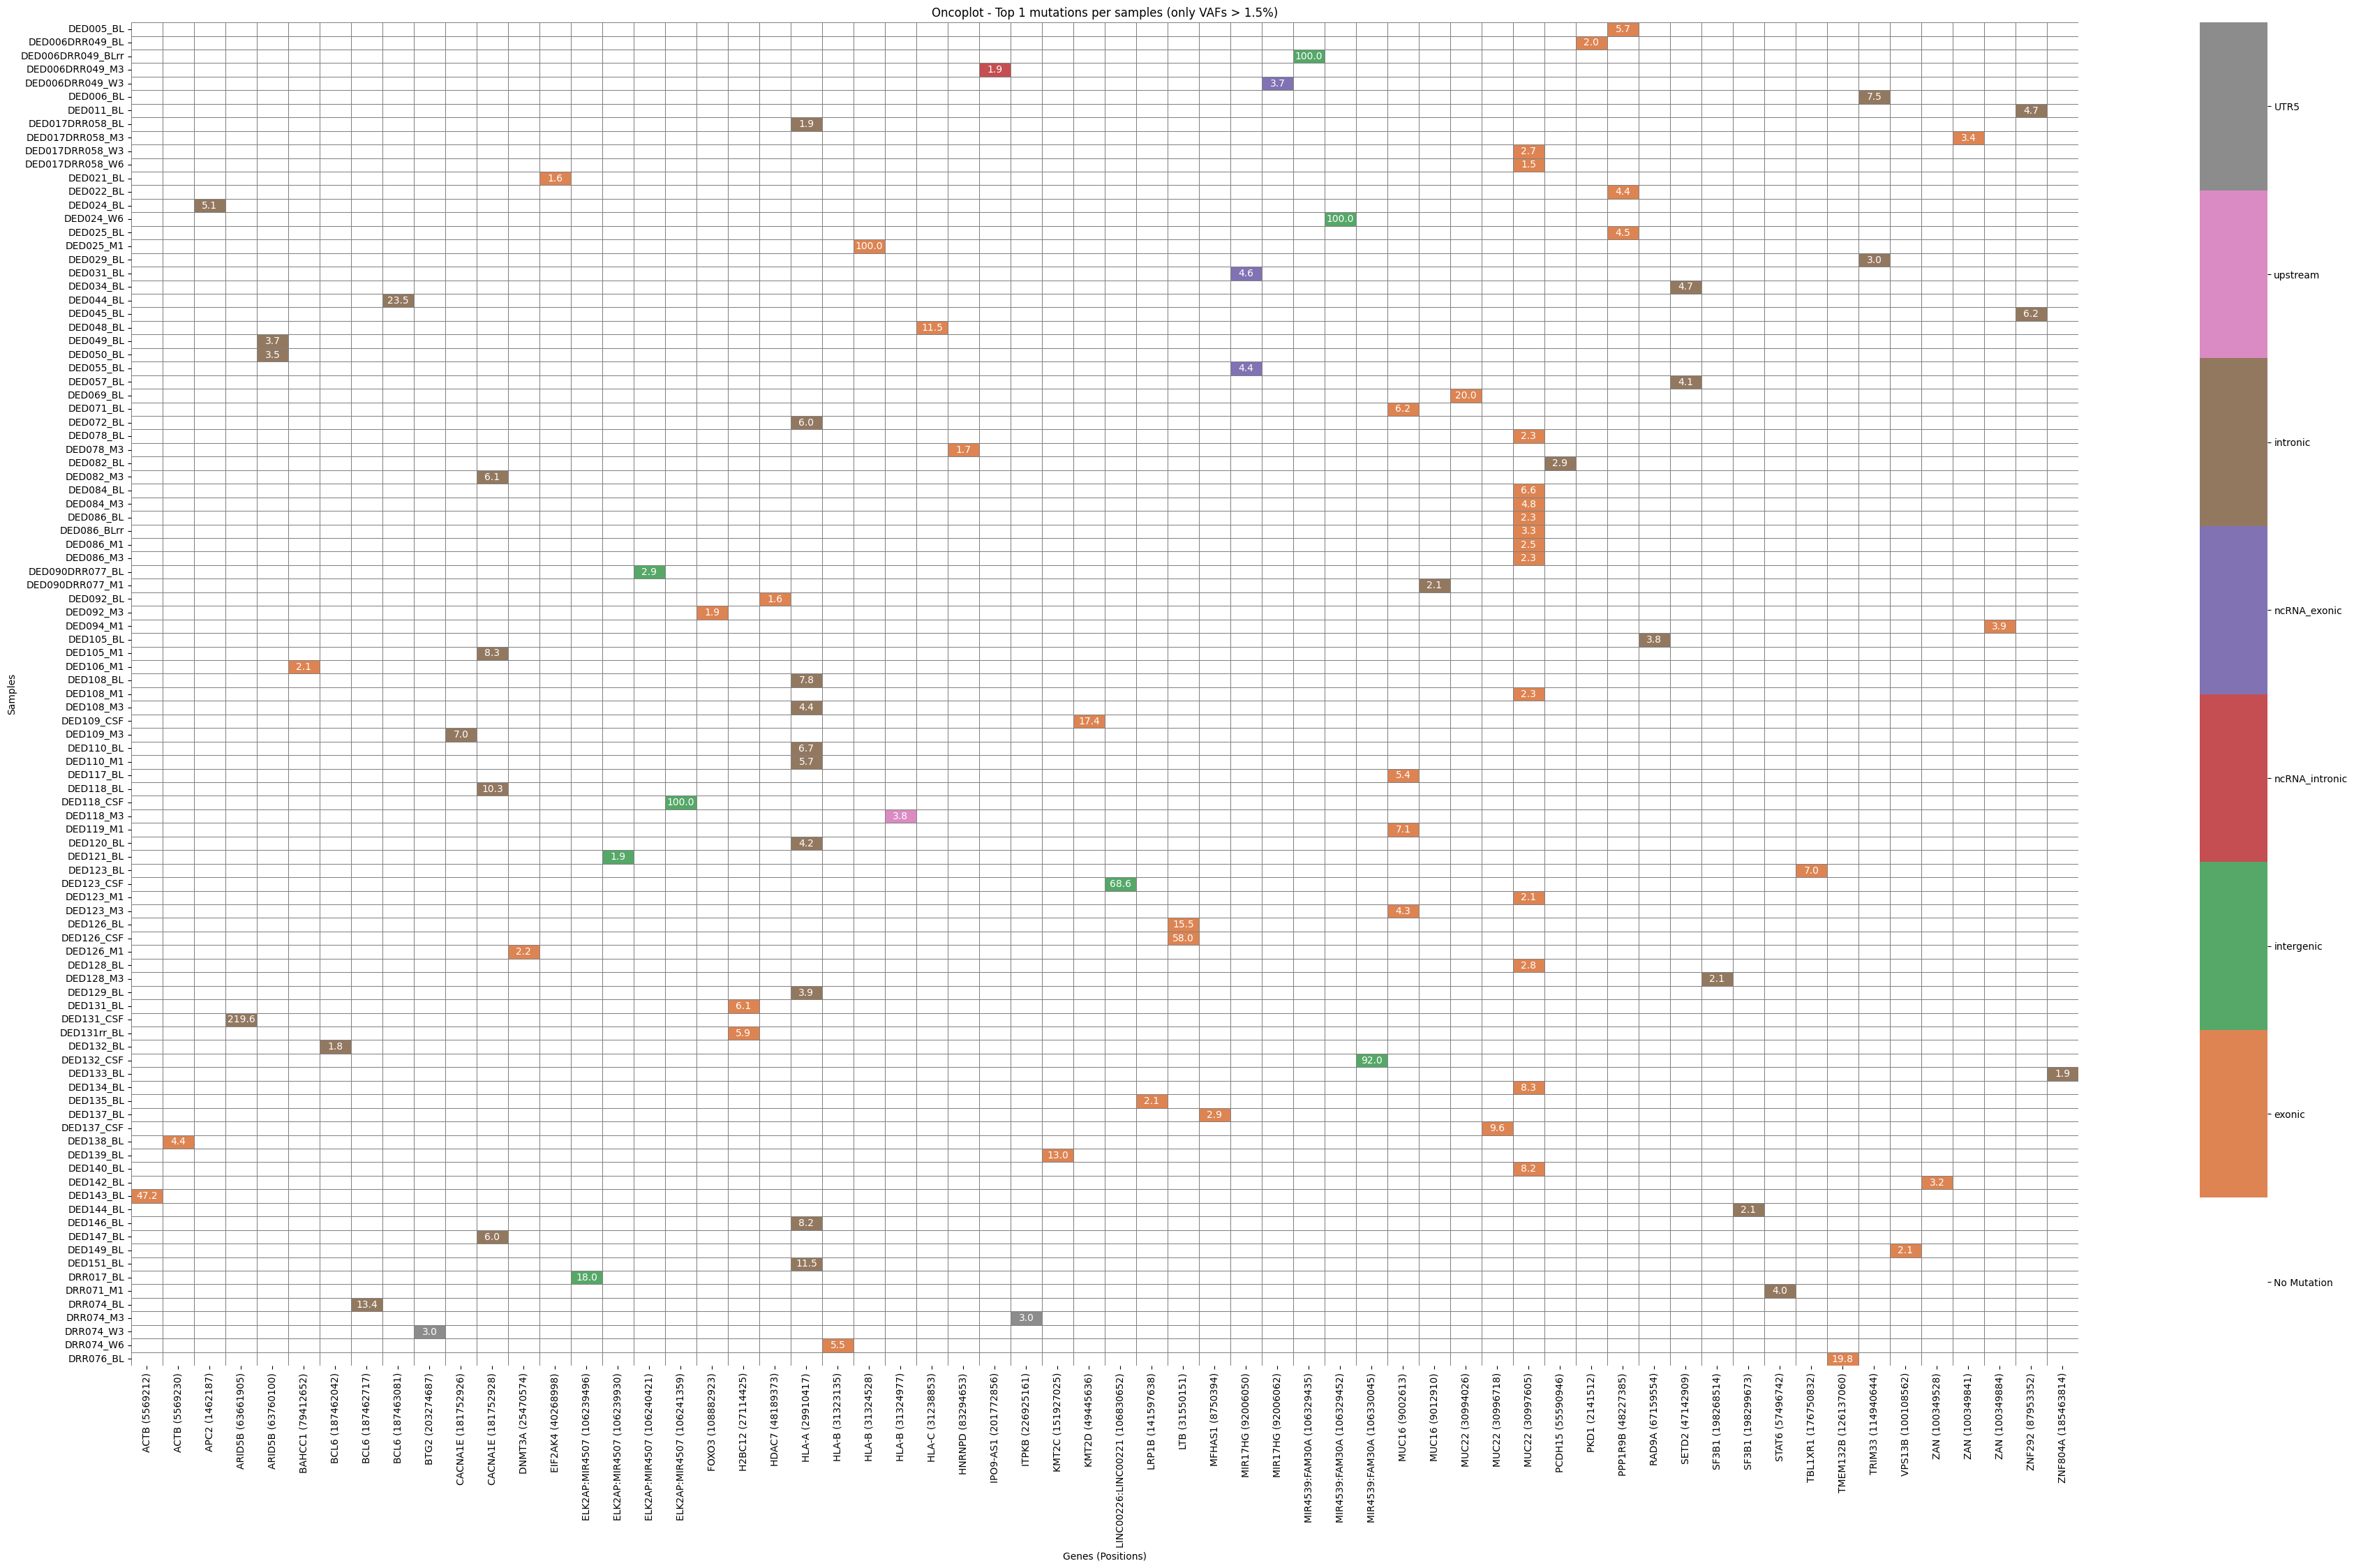

In [5]:
if __name__ == "__main__":
    vcf_files: list[str] = glob.glob("/mnt/ramses/projects/ag-schwarzr/project-lymphoma-cfdna/PCNSL/mutations/*.vcf")
    filter_vaf: float = 1.5
    top_n: int = 1
    mutation_matrix, vaf_matrix = load_vcf_files(vcf_files[:], filter_vaf=filter_vaf, top_n=top_n)
    plot_oncoplot(mutation_matrix, vaf_matrix,
                  title=f"Oncoplot - Top {top_n} mutations per samples (only VAFs > {filter_vaf}%)")